In [1]:
import numpy as np
rng = np.random.default_rng(42)

N_BITS = 1_000_000
bits = rng.integers(0, 2, N_BITS)
b = bits.reshape(-1, 2)          # take bits two at a time

I = 1 - 2*b[:, 0]                # 0 -> +1,  1 -> -1
Q = 1 - 2*b[:, 1]
x = (I + 1j*Q) / np.sqrt(2)      # Es = 1 (each point has |x|^2 = 1)

In [2]:
k = 2                            # bits per symbol (QPSK)
ebn0_db = 4                      # try one point first
ebn0 = 10**(ebn0_db/10)          # dB -> linear

N0 = 1 / (k * ebn0)              # derivation below
sigma = np.sqrt(N0/2)            # std dev PER REAL DIMENSION

n = sigma * (rng.standard_normal(len(x)) + 1j*rng.standard_normal(len(x)))
r = x + n

In [3]:
b0_hat = (r.real < 0).astype(int)
b1_hat = (r.imag < 0).astype(int)
bits_hat = np.column_stack([b0_hat, b1_hat]).ravel()
ber = np.mean(bits_hat != bits)
print(ber)

0.012548


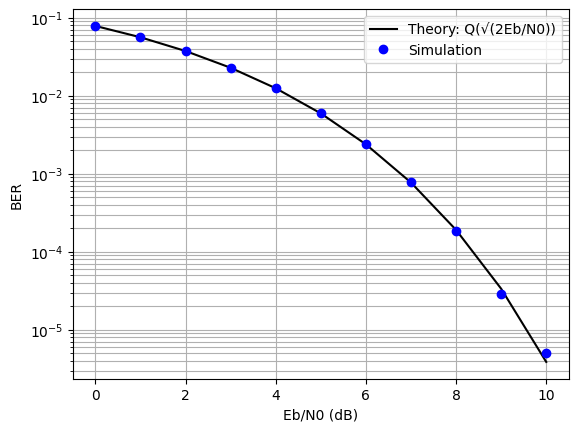

In [4]:
from scipy.special import erfc
import matplotlib.pyplot as plt

def Qfunc(z): return 0.5*erfc(z/np.sqrt(2))

EbN0_dB = np.arange(0, 11)
ber_sim = []
for db in EbN0_dB:
    ebn0 = 10**(db/10)
    sigma = np.sqrt(1/(2*k*ebn0))
    n = sigma*(rng.standard_normal(len(x)) + 1j*rng.standard_normal(len(x)))
    r = x + n
    bh = np.column_stack([(r.real<0), (r.imag<0)]).astype(int).ravel()
    ber_sim.append(np.mean(bh != bits))

ber_theory = Qfunc(np.sqrt(2*10**(EbN0_dB/10)))

plt.semilogy(EbN0_dB, ber_theory, 'k-', label='Theory: Q(√(2Eb/N0))')
plt.semilogy(EbN0_dB, ber_sim, 'bo', label='Simulation')
plt.xlabel('Eb/N0 (dB)'); plt.ylabel('BER'); plt.grid(True, which='both')
plt.legend(); plt.show()

In [5]:
import torch, torch.nn as nn, torch.nn.functional as F
torch.manual_seed(0)

k, M, n_ch = 2, 4, 1        # 2 bits -> 4 messages -> 1 complex symbol

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(M, 64), nn.ReLU(),
            nn.Linear(64, 2*n_ch)      # outputs [I, Q]
        )

    def forward(self, s):
      x = self.net(s)
      power = x.pow(2).sum(dim=1).mean()      # E[|x|^2] over the batch
      x = x / torch.sqrt(power)               # rescale so E[|x|^2] = 1
      return x

enc = Encoder()
s = F.one_hot(torch.arange(M), M).float()   # all 4 messages
print(enc(s))

tensor([[1.1517, 0.3880],
        [0.7346, 0.0445],
        [0.4204, 0.6743],
        [1.1301, 0.2696]], grad_fn=<DivBackward0>)


In [6]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2*n_ch, 64), nn.ReLU(),
            nn.Linear(64, M)          # M logits, one per message
        )
    def forward(self, r):
        return self.net(r)

dec = Decoder()
print(dec(enc(s)).shape)      # expect: torch.Size([4, 4])

torch.Size([4, 4])


In [7]:
def awgn(x, sigma):
    return x + sigma * torch.randn_like(x)

import numpy as np
def ebn0_to_sigma(ebn0_db, k):
    ebn0 = 10**(ebn0_db/10)
    return np.sqrt(1/(2*k*ebn0))     # same derivation as your QPSK cell

In [8]:
model_params = list(enc.parameters()) + list(dec.parameters())
opt = torch.optim.Adam(model_params, lr=1e-3)
lossf = nn.CrossEntropyLoss()

sigma = ebn0_to_sigma(7.0, k)      # train at 7 dB

for step in range(10000):
    m = torch.randint(0, M, (1024,))        # random messages
    s = F.one_hot(m, M).float()             # -> one-hot
    x = enc(s)                              # transmitter
    r = awgn(x, sigma)                      # channel
    logits = dec(r)                         # receiver
    loss = lossf(logits, m)                 # did we recover m?

    opt.zero_grad(); loss.backward(); opt.step()

    if (step+1) % 2000 == 0:
        print(f"step {step+1:5d}   loss {loss.item():.4f}")

step  2000   loss 0.0050
step  4000   loss 0.0010
step  6000   loss 0.0021
step  8000   loss 0.0025
step 10000   loss 0.0128


In [9]:
with torch.no_grad():
    C = enc(F.one_hot(torch.arange(M), M).float())
print(C)
print("per-symbol energy |x|^2:", C.pow(2).sum(dim=1))
print("mean energy E[|x|^2]  :", C.pow(2).sum(dim=1).mean())

tensor([[-0.5750,  0.8073],
        [ 0.5554, -0.7833],
        [-0.8222, -0.6063],
        [ 0.8260,  0.6080]])
per-symbol energy |x|^2: tensor([0.9824, 0.9221, 1.0436, 1.0520])
mean energy E[|x|^2]  : tensor(1.)


learned constellation:
  msg 00: (-0.575, +0.807)   |x|^2 = 0.982
  msg 01: (+0.555, -0.783)   |x|^2 = 0.922
  msg 10: (-0.822, -0.606)   |x|^2 = 1.044
  msg 11: (+0.826, +0.608)   |x|^2 = 1.052

min distance = 1.389    QPSK optimum = 1.414


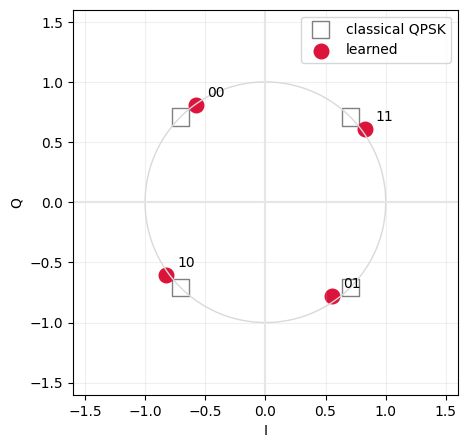

In [10]:
import matplotlib.pyplot as plt
import numpy as np

with torch.no_grad():
    C = enc(F.one_hot(torch.arange(M), M).float()).numpy()

print("learned constellation:")
for i, p in enumerate(C):
    print(f"  msg {i:02b}: ({p[0]:+.3f}, {p[1]:+.3f})   |x|^2 = {(p**2).sum():.3f}")

d = [np.linalg.norm(C[i]-C[j]) for i in range(4) for j in range(i+1,4)]
print(f"\nmin distance = {min(d):.3f}    QPSK optimum = {np.sqrt(2):.3f}")

qpsk = np.array([[1,1],[1,-1],[-1,1],[-1,-1]])/np.sqrt(2)
th = np.linspace(0, 2*np.pi, 200)
plt.figure(figsize=(5,5))
plt.plot(np.cos(th), np.sin(th), color='0.85', lw=1)          # power budget
plt.scatter(qpsk[:,0], qpsk[:,1], s=160, facecolors='none',
            edgecolors='gray', marker='s', label='classical QPSK')
plt.scatter(C[:,0], C[:,1], s=110, c='crimson', label='learned')
for i,p in enumerate(C):
    plt.annotate(f"{i:02b}", p, xytext=(8,6), textcoords='offset points')
plt.axhline(0, color='0.9'); plt.axvline(0, color='0.9')
plt.gca().set_aspect('equal'); plt.xlim(-1.6,1.6); plt.ylim(-1.6,1.6)
plt.xlabel('I'); plt.ylabel('Q'); plt.legend(); plt.grid(alpha=0.2)
plt.show()


In [11]:
k, M, n_ch = 4, 16, 1          # 16 messages, still ONE complex symbol

enc, dec = Encoder(), Decoder()          # fresh weights
opt = torch.optim.Adam(list(enc.parameters()) + list(dec.parameters()), lr=1e-3)
lossf = nn.CrossEntropyLoss()

sigma = ebn0_to_sigma(12.0, k)           # higher SNR: 16 points are packed tighter
print("sigma =", sigma)

sigma = 0.08880859646454513


In [12]:
for step in range(20000):
    m = torch.randint(0, M, (1024,))
    x = enc(F.one_hot(m, M).float())
    r = awgn(x, sigma)
    loss = lossf(dec(r), m)
    opt.zero_grad(); loss.backward(); opt.step()
    if (step+1) % 4000 == 0:
        print(f"step {step+1:6d}   loss {loss.item():.4f}")

step   4000   loss 0.0077
step   8000   loss 0.0025
step  12000   loss 0.0014
step  16000   loss 0.0006
step  20000   loss 0.0011


In [13]:
with torch.no_grad():
    C = enc(F.one_hot(torch.arange(M), M).float()).numpy()

rad = np.linalg.norm(C, axis=1)
ang = np.degrees(np.arctan2(C[:,1], C[:,0])) % 360

print("mean energy:", (C**2).sum(1).mean().round(4), " (should be 1.0)")
print("\nsorted radii:", np.sort(rad).round(3))

order = np.argsort(rad)
print("\npoint | radius | angle")
for i in order:
    print(f"  {i:2d}  |  {rad[i]:.3f} | {ang[i]:6.1f}°")

d = [np.linalg.norm(C[i]-C[j]) for i in range(M) for j in range(i+1,M)]
print(f"\nmin distance = {min(d):.3f}")

mean energy: 1.0  (should be 1.0)

sorted radii: [0.361 0.392 0.454 0.665 0.714 0.819 1.027 1.044 1.076 1.092 1.127 1.131
 1.162 1.305 1.346 1.407]

point | radius | angle
   2  |  0.361 |   51.9°
   8  |  0.392 |  192.6°
   5  |  0.454 |  313.7°
  13  |  0.665 |  120.2°
   9  |  0.714 |  252.1°
  11  |  0.819 |    1.2°
  12  |  1.027 |   45.6°
   6  |  1.044 |  187.9°
  15  |  1.076 |   84.7°
   0  |  1.092 |  287.9°
  14  |  1.127 |  153.6°
  10  |  1.131 |  325.8°
   7  |  1.162 |  223.6°
   4  |  1.305 |  117.1°
   1  |  1.346 |  258.5°
   3  |  1.407 |   16.1°

min distance = 0.611


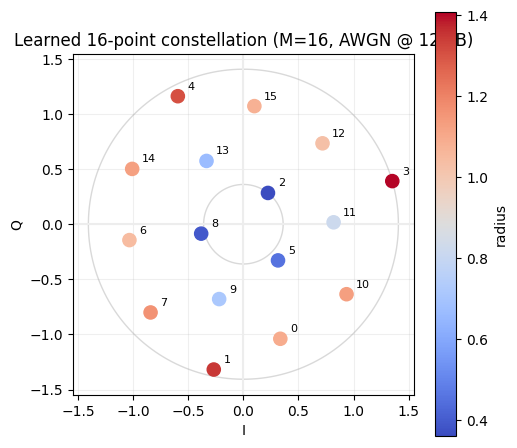

In [14]:
th = np.linspace(0, 2*np.pi, 200)
plt.figure(figsize=(5.5,5.5))
for rr in [rad.min(), rad.max()]:                 # guide circles at inner/outer radius
    plt.plot(rr*np.cos(th), rr*np.sin(th), color='0.85', lw=1, zorder=0)
plt.scatter(C[:,0], C[:,1], s=90, c=rad, cmap='coolwarm', zorder=3)
for i,p in enumerate(C):
    plt.annotate(str(i), p, xytext=(7,5), textcoords='offset points', fontsize=8)
plt.axhline(0, color='0.93'); plt.axvline(0, color='0.93')
plt.gca().set_aspect('equal'); plt.xlabel('I'); plt.ylabel('Q')
plt.title(f'Learned 16-point constellation (M=16, AWGN @ 12 dB)')
plt.grid(alpha=0.2); plt.colorbar(label='radius')
plt.show()